In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("insurance_extended.csv")

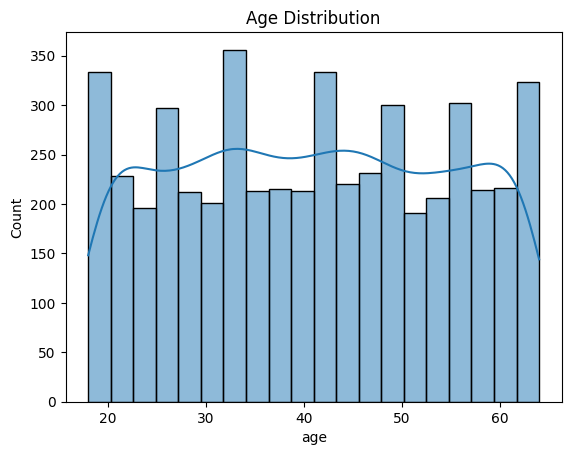

In [54]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

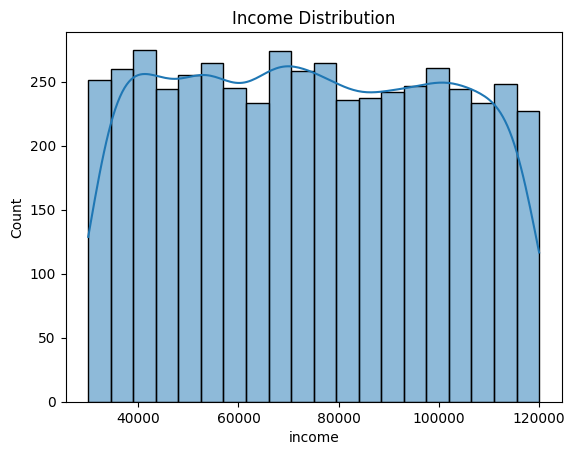

In [55]:
plt.figure()
sns.histplot(df['income'], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

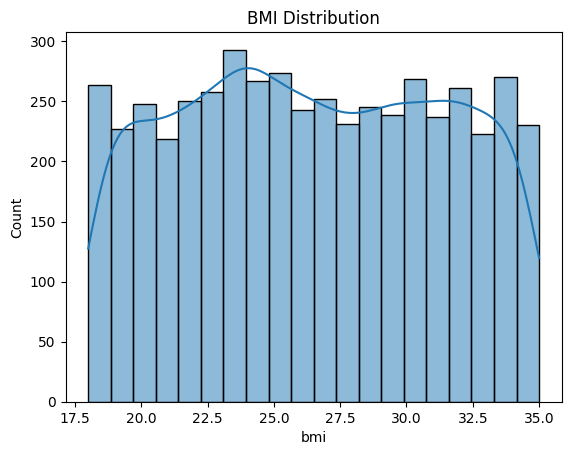

In [56]:
plt.figure()
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

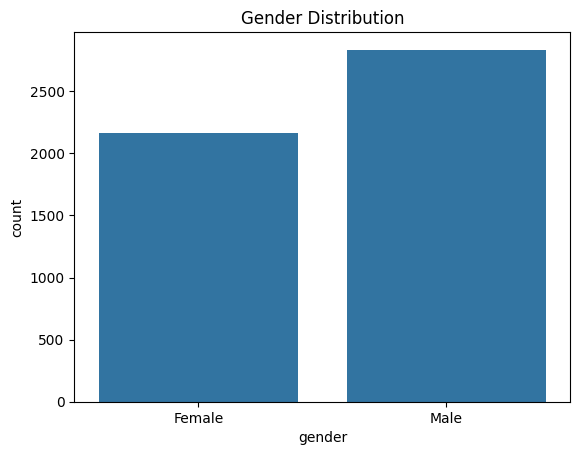

In [57]:
plt.figure()
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

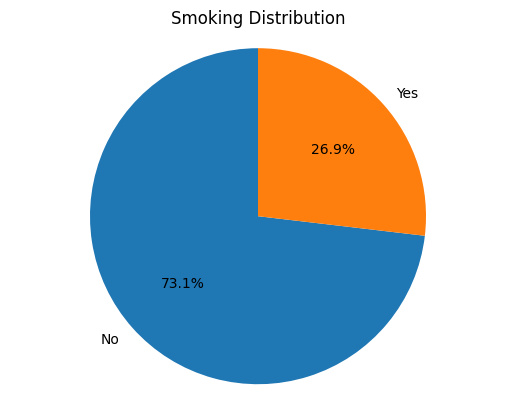

In [58]:
plt.figure()
counts = df['smoker'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Smoking Distribution")
plt.axis('equal')
plt.show()

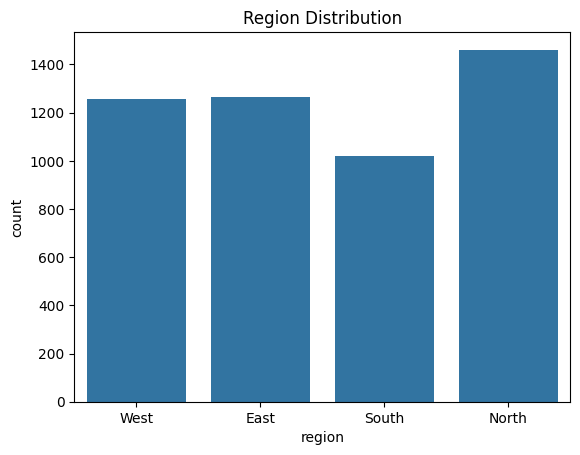

In [59]:
plt.figure()
sns.countplot(x='region', data=df)
plt.title("Region Distribution")
plt.show()

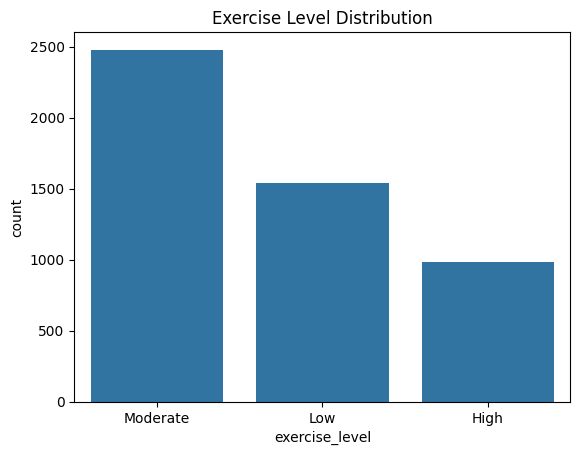

In [60]:
plt.figure()
sns.countplot(x='exercise_level', data=df)
plt.title("Exercise Level Distribution")
plt.show()

In [62]:
# BIVARIATE ANALYSIS

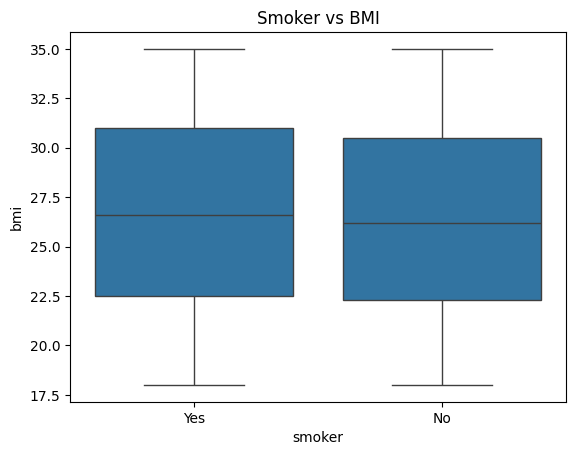

In [61]:
plt.figure()
sns.boxplot(x='smoker', y='bmi', data=df)
plt.title("Smoker vs BMI")
plt.show()

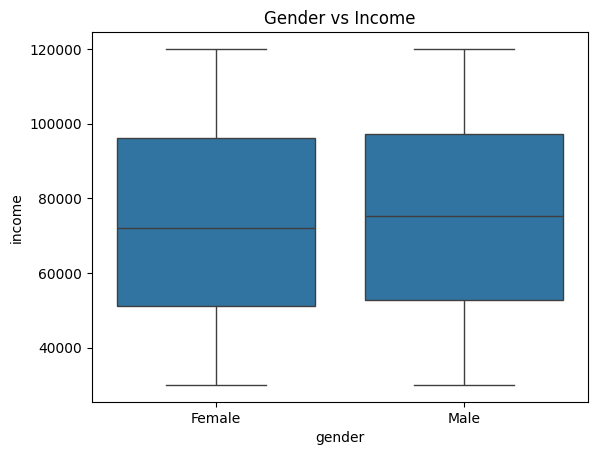

In [63]:
plt.figure()
sns.boxplot(x='gender', y='income', data=df)
plt.title("Gender vs Income")
plt.show()

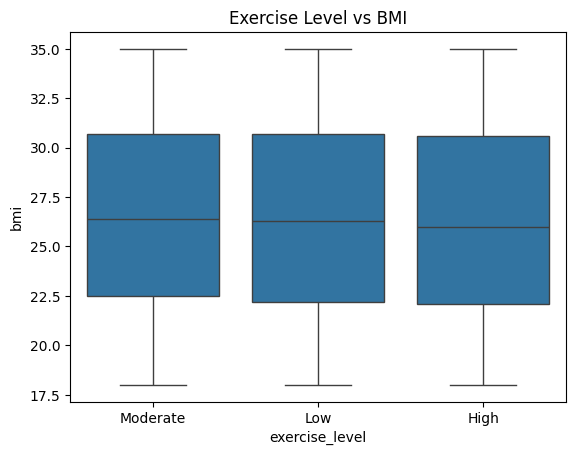

In [64]:
plt.figure()
sns.boxplot(x='exercise_level', y='bmi', data=df)
plt.title("Exercise Level vs BMI")
plt.show()

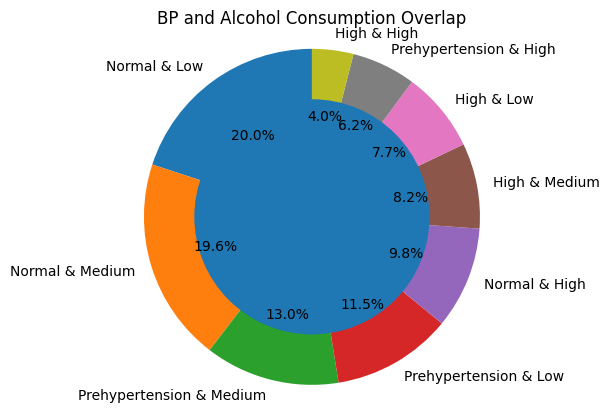

In [65]:
plt.figure()

# Create combinations
combo = df['BP'] + " & " + df['alcohol']
counts = combo.value_counts()

labels = counts.index
sizes = counts.values

wedges, texts, autotexts = plt.pie(
    sizes, labels=labels, autopct='%1.1f%%', startangle=90
)

# Donut effect
centre_circle = plt.Circle((0,0), 0.70)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("BP and Alcohol Consumption Overlap")
plt.axis('equal')
plt.show()

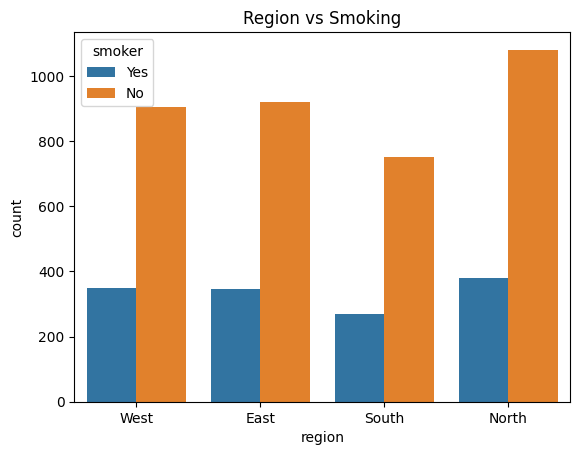

In [67]:
plt.figure()
sns.countplot(x='region', hue='smoker', data=df)
plt.title("Region vs Smoking")
plt.show()

In [68]:
# MULTIVARIATE ANALYSIS

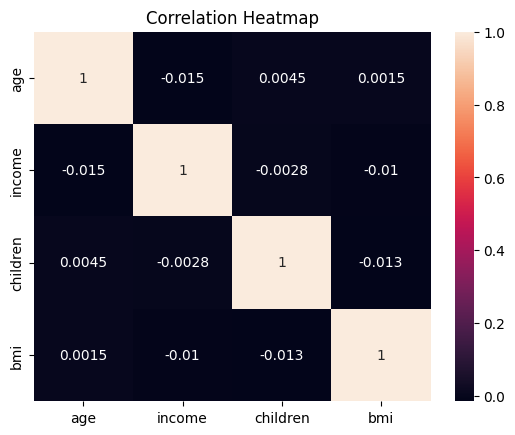

In [69]:
plt.figure()
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

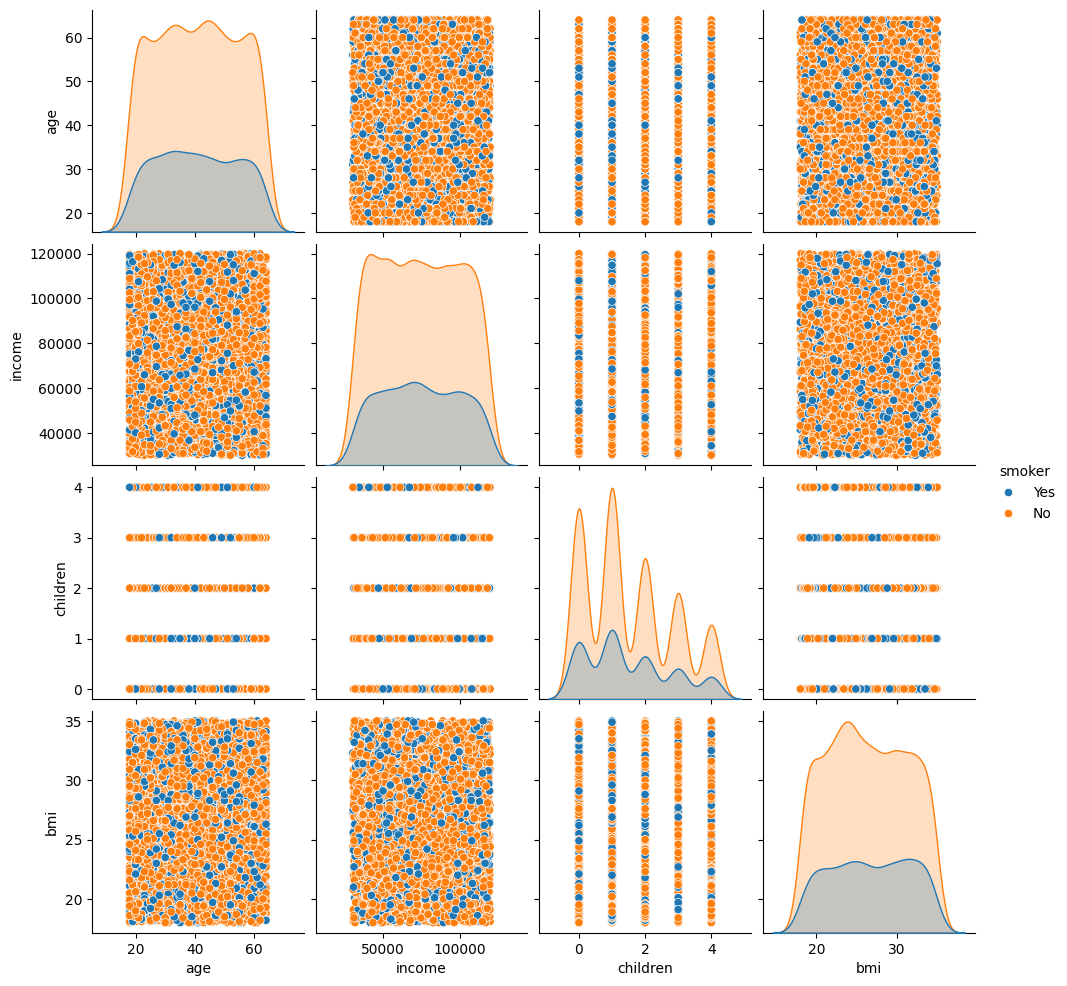

In [70]:
sns.pairplot(df, hue='smoker')
plt.show()

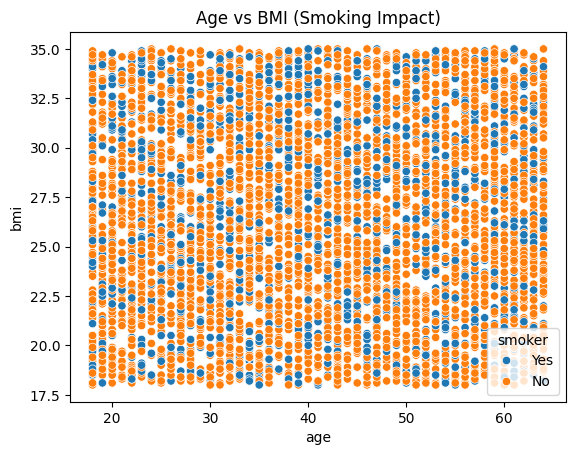

In [71]:
plt.figure()
sns.scatterplot(x='age', y='bmi', hue='smoker', data=df)
plt.title("Age vs BMI (Smoking Impact)")
plt.show()

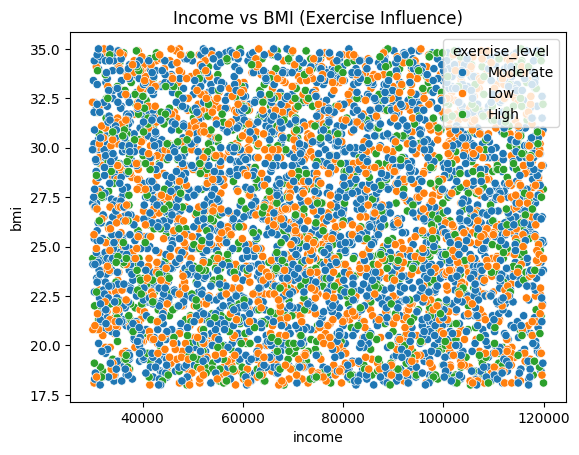

In [72]:
plt.figure()
sns.scatterplot(x='income', y='bmi', hue='exercise_level', data=df)
plt.title("Income vs BMI (Exercise Influence)")
plt.show()

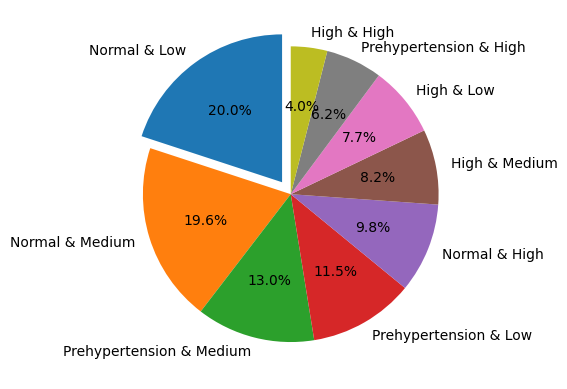

In [75]:
explode = [0] * len(sizes)
explode[0] = 0.1

plt.pie(sizes, labels=labels, autopct='%1.1f%%', explode=explode, startangle=90)
plt.show()

In [ ]:
MODEL PREDICTION

In [78]:
def assign_claim(row):
    risk = 0
    
    if row['smoker'] == 'Yes':
        risk += 3
    if row['heart_disease'] == 'Yes':
        risk += 3
    if row['diabetes'] == 'Yes':
        risk += 2
    if row['BP'] == 'High':
        risk += 2
    if row['bmi'] > 30:
        risk += 2
    
    if row['exercise_level'] == 'Low':
        risk += 1
    if row['alcohol'] == 'High':
        risk += 1
    
    return 0 if risk >= 6 else 1

df['claim_status'] = df.apply(assign_claim, axis=1)

In [ ]:
BASE_AMOUNT = 100000

def calculate_claim_amount(row):
    
    if row['claim_status'] == 0:
        return 0
    
    amount = BASE_AMOUNT
    
    if row['age'] > 50:
        amount *= 0.98
    if row['bmi'] > 30:
        amount *= 0.97
    if row['smoker'] == 'Yes':
        amount *= 0.95
    if row['BP'] == 'High':
        amount *= 0.97
    if row['diabetes'] == 'Yes':
        amount *= 0.98
    if row['heart_disease'] == 'Yes':
        amount *= 0.94
    if row['exercise_level'] == 'Low':
        amount *= 0.98
    if row['alcohol'] == 'High':
        amount *= 0.98
    
    return round(amount, 2)


In [98]:
df['claim_amount'] = df.apply(calculate_claim_amount, axis=1)

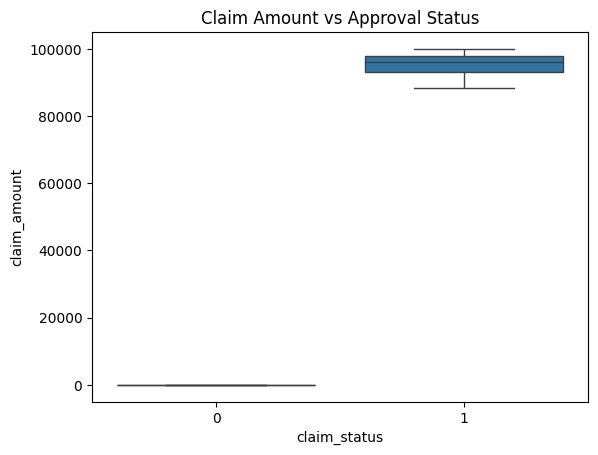

In [80]:
plt.figure()
sns.boxplot(x='claim_status', y='claim_amount', data=df)
plt.title("Claim Amount vs Approval Status")
plt.show()

In [81]:
# Encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Features (X) and Target (y)
X = df_encoded.drop(['claim_status', 'claim_amount'], axis=1)
y = df_encoded['claim_status']

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [83]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [84]:
y_pred = model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value':  [accuracy, precision, recall, f1]
})

print(metrics_df)

      Metric     Value
0   Accuracy  0.967000
1  Precision  0.964874
2     Recall  0.998864
3   F1 Score  0.981575


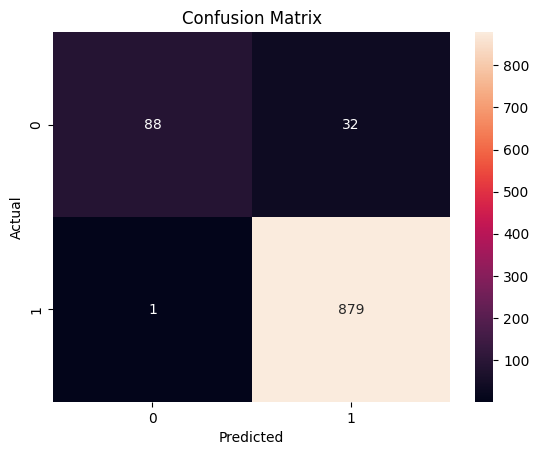

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       120
           1       0.96      1.00      0.98       880

    accuracy                           0.97      1000
   macro avg       0.98      0.87      0.91      1000
weighted avg       0.97      0.97      0.96      1000



In [88]:
import pandas as pd

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

               Feature  Importance
10          smoker_Yes    0.224843
3                  bmi    0.162425
17   heart_disease_Yes    0.105025
1               income    0.077334
7         diabetes_Yes    0.071539
0                  age    0.063211
8            BP_Normal    0.047722
5   exercise_level_Low    0.040128
9   BP_Prehypertension    0.032708
2             children    0.030980


In [89]:
def get_user_input():
    data = {
        'age': int(input("Enter Age: ")),
        'income': int(input("Enter Income: ")),
        'children': int(input("Enter Number of Children: ")),
        'bmi': float(input("Enter BMI: ")),
        
        'gender': input("Gender (Male/Female): "),
        'exercise_level': input("Exercise Level (Low/Moderate/High): "),
        'diabetes': input("Diabetes (Yes/No): "),
        'BP': input("BP (Normal/Prehypertension/High): "),
        'smoker': input("Smoker (Yes/No): "),
        'alcohol': input("Alcohol (Low/Medium/High): "),
        'region': input("Region (North/East/West/South): "),
        'thyroid': input("Thyroid (Yes/No): "),
        'heart_disease': input("Heart Disease (Yes/No): "),
        'asthma': input("Asthma (Yes/No): "),
        'allergies': input("Allergies (Yes/No): ")
    }
    
    return pd.DataFrame([data])

In [90]:
def preprocess_input(input_df, X_columns):
    input_encoded = pd.get_dummies(input_df)
    
    # Add missing columns
    for col in X_columns:
        if col not in input_encoded:
            input_encoded[col] = 0
    
    # Ensure same order
    input_encoded = input_encoded[X_columns]
    
    return input_encoded

In [93]:
def predict_claim():
    user_df = get_user_input()
    
    processed = preprocess_input(user_df, X.columns)
    
    prediction = model.predict(processed)[0]
    
    if prediction == 1:
        print("✅ Claim Approved")
        
        # Calculate amount
        user_df['claim_status'] = 1
        amount = calculate_claim_amount(user_df.iloc[0])
        
        print(f"💰 Claim Amount: {amount}")
        
    else:
        print("❌ Claim Rejected")
        print("💰 Claim Amount: 0")

In [92]:
predict_claim()

ValueError: invalid literal for int() with base 10: ''